# Section 1

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from datetime import datetime
from statistics import mean, stdev, log
from statsmodels.tsa.stattools import adfuller

In [2]:
f = open("top100coins.txt", "r")
lines = f.read().split("\n")
coins = lines[1::5]
coins_prices = {}
for coin in coins:
    data = yf.Ticker(coin).history(
        interval="1d", start=datetime(2023, 12, 1), end=datetime(2024, 12, 1)
    )
    
    if not data.empty:
        coins_prices[coin] = data.Close
coins_prices = pd.DataFrame(coins_prices)

$HYPE32196-USD: possibly delisted; no price data found  (1d 2023-12-01 00:00:00 -> 2024-12-01 00:00:00)
$USDS33039-USD: possibly delisted; no price data found  (1d 2023-12-01 00:00:00 -> 2024-12-01 00:00:00)
$RENDER-USD: possibly delisted; no price data found  (1d 2023-12-01 00:00:00 -> 2024-12-01 00:00:00)
$CBBTC32994-USD: possibly delisted; no price data found  (1d 2023-12-01 00:00:00 -> 2024-12-01 00:00:00)
$MOVE32452-USD: possibly delisted; no price data found  (1d 2023-12-01 00:00:00 -> 2024-12-01 00:00:00)
$LBTC33652-USD: possibly delisted; no price data found  (1d 2023-12-01 00:00:00 -> 2024-12-01 00:00:00)
$KAIA-USD: possibly delisted; no price data found  (1d 2023-12-01 00:00:00 -> 2024-12-01 00:00:00)
$SOLVBTC-USD: possibly delisted; no price data found  (1d 2023-12-01 00:00:00 -> 2024-12-01 00:00:00)


In [3]:
stationary_coins_data1 = []
for coin in coins_prices.columns:
    if adfuller(coins_prices[coin].dropna())[1] < 0.05:
        stationary_coins_data1.append(coin)

stationary_coins_data1 = coins_prices[stationary_coins_data1]

In [4]:
stationary_coins_data2 = []
for coin in coins_prices.columns:
    res = adfuller(coins_prices[coin].dropna())
    statistic_res = res[0]
    critical_val = res[4]["5%"]
    if statistic_res < critical_val:
        stationary_coins_data2.append(coin)

stationary_coins_data2 = coins_prices[stationary_coins_data2]

In [5]:
print("Stationary coins of first approach:")
for coin in stationary_coins_data1:
    print(coin)

print("Stationary coins of second approach:")
for coin in stationary_coins_data2:
    print(coin)


Stationary coins of first approach:
USDT-USD
USDC-USD
DAI-USD
FDUSD-USD
Stationary coins of second approach:
USDT-USD
USDC-USD
DAI-USD
FDUSD-USD


# Section 2

In two below cells, Hurst Exponential criteria is implemented. Implementation
is done using below site:
https://blog.quantinsti.com/hurst-exponent/

In [6]:
def Divide_Chunks(series: pd.DataFrame, column) -> list:
    different_chunks = []
    series = series.copy().reset_index(drop=True, inplace=False)
    len_series = len(series)
    while len_series > 1:
        temp = pd.DataFrame(
            {
                i: series.loc[i * len_series : (i + 1) * len_series - 1, column].values
                for i in range(len(series) // len_series)
            },
            index=[i for i in range(len_series)],
        )
        different_chunks.append(temp)
        len_series = len_series // 2
    return different_chunks

In [7]:
def Hurst_Exponent(series: pd.DataFrame, column):
    divided_chunks = Divide_Chunks(series, column)
    means = [chunk.apply(mean) for chunk in divided_chunks]
    stds = [chunk.apply(stdev) for chunk in divided_chunks]
    for index, chunk in enumerate(divided_chunks):
        chunk -= means[index]
    cumsum = [chunk.cumsum() for chunk in divided_chunks]
    r_n = [chunk.max() - chunk.min() for chunk in cumsum]
    for index, r in enumerate(r_n):
        r /= stds[index]
    mean_r = [r.mean() for r in r_n]
    log_r = []
    log_size = []
    for index, m_r in enumerate(mean_r):
        log_r.append(log(m_r))
        log_size.append(log(len(divided_chunks[index].index)))

    slope_intercept = np.polyfit(log_size, log_r, 1)
    return slope_intercept[0]

In [8]:
coins_hurst_value = [
    (coin, Hurst_Exponent(stationary_coins_data1, coin))
    for coin in stationary_coins_data1
]
coins_hurst_value.sort(key=lambda x: x[1])

print(coins_hurst_value)

[('FDUSD-USD', 0.8008316802684409), ('DAI-USD', 0.8018268884393122), ('USDC-USD', 0.8511320306414738), ('USDT-USD', 0.8742905063020255)]


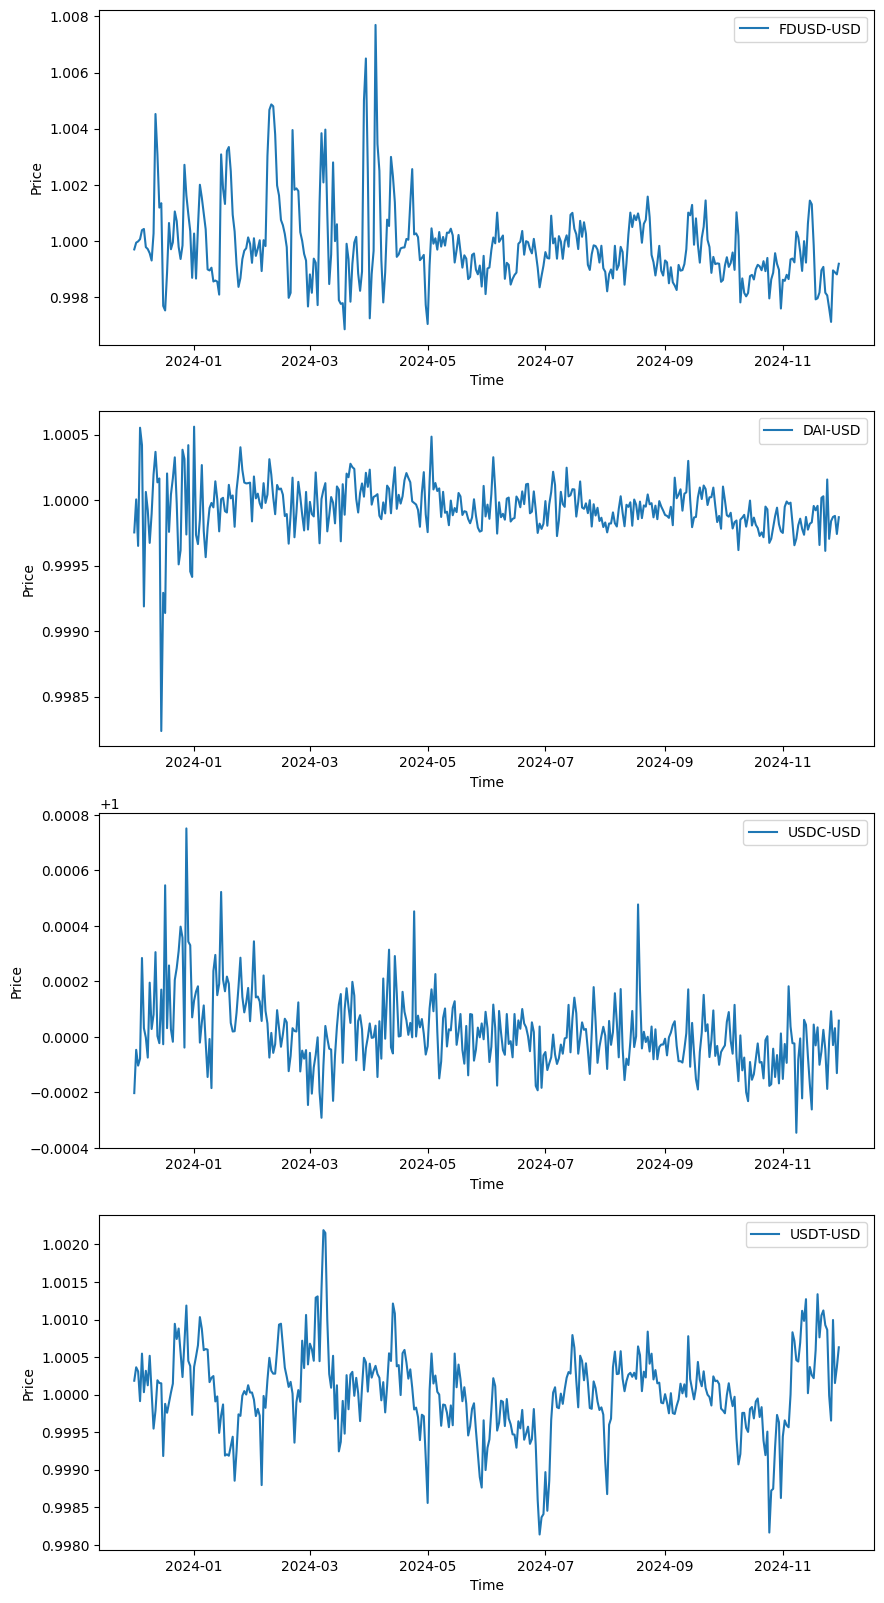

In [9]:
plt.figure(figsize=(10, 20))
for index, (coin, _) in enumerate(coins_hurst_value):
    plt.subplot(4, 1, index + 1)
    plt.plot(stationary_coins_data1[coin], label=coin)
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.legend()

plt.show()

In [10]:
def Halflife(series: pd.DataFrame, column):
    series = series[column].copy()
    x = series.iloc[1:]
    x = np.vstack([x, np.ones(len(x))]).T
    y = series.iloc[:-1]
    lambda_ = np.linalg.lstsq(x, y, rcond=None)[0][0] - 1
    return -log(2) / lambda_

In [11]:
for coin in stationary_coins_data1:
    print(f"{coin}, Half-Life : {Halflife(stationary_coins_data1, coin)}")

USDT-USD, Half-Life : 2.7843297870679975
USDC-USD, Half-Life : 1.1078673368976077
DAI-USD, Half-Life : 0.8766944236843347
FDUSD-USD, Half-Life : 1.828485706486661
